In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
file_name = 'Healthcare Messy Data copy.csv'
df = pd.read_csv(file_name)
print(f"Data loaded from {file_name}. First 5 rows:")
display(df.head(10))

Data loaded from Healthcare Messy Data copy.csv. First 5 rows:


,Patient Name,Age,Gender,Condition,Medication,Visit Date,Blood Pressure,Cholesterol,Email,Phone Number
0,david lee,25,Other,Heart Disease,METFORMIN,01/15/2020,140/90,200.0,name@hospital.org,555-555-5555
1,emily davis,NaN,Male,Diabetes,NONE,"April 5, 2018",120/80,200.0,NaN,NaN
2,laura martinez,35,Other,Asthma,METFORMIN,2019.12.01,110/70,160.0,contact@domain.com,NaN
3,michael wilson,NaN,Male,Diabetes,ALBUTEROL,01/15/2020,110/70,NaN,name@hospital.org,555-555-5555
4,david lee,NaN,Female,Asthma,NONE,2020/02/20,110/70,180.0,NaN,
5,mary clark,NaN,Male,Hypertension,METFORMIN,03-25-2019,140/90,180.0,NaN,NaN
6,robert brown,NaN,Male,Hypertension,LISINOPRIL,2020/02/20,120/80,NaN,name@hospital.org,NaN
7,david lee,60,Other,NaN,NONE,2020/02/20,NaN,NaN,name@hospital.org,NaN
8,laura martinez,60,Other,Heart Disease,NONE,01/15/2020,140/90,180.0,name@hospital.org,NaN
9,michael wilson,forty,Female,NaN,ALBUTEROL,2020/02/20,140/90,220.0,patient@example.com,555-555-5555


In [13]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Patient Name    1000 non-null   object 
 1   Age             841 non-null    object 
 2   Gender          1000 non-null   object 
 3   Condition       794 non-null    object 
 4   Medication      1000 non-null   object 
 5   Visit Date      1000 non-null   object 
 6   Blood Pressure  834 non-null    object 
 7   Cholesterol     769 non-null    float64
 8   Email           616 non-null    object 
 9   Phone Number    821 non-null    object 
dtypes: float64(1), object(9)
memory usage: 78.3+ KB
None
Patient Name        0
Age               159
Gender              0
Condition         206
Medication          0
Visit Date          0
Blood Pressure    166
Cholesterol       231
Email             384
Phone Number      179
dtype: int64


based on the initial inspection, the dataset contains 1000 entries with and 10 columns from patient name to phone number. However, the data has formatting issues, missing data, and wrong data types especially in the visit data column.

In [20]:
# this phase will be data cleaning

# the first thing to do is to fix standardazing the text column
df['Patient Name'] = df['Patient Name'].str.title()

# this code is hidden spaces from string columns and also replacing nan string to a nan value
string_cols = ['Gender', 'Condition', 'Medication', 'Email', 'Phone Number']
for col in string_cols:
    df[col] = df[col].astype(str).str.strip()
    df[col] = df[col].replace('nan', np.nan)

# age columns is not all numeric because row 9 it says forty instead of 40
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
# some ages are not mentioned so i will fill it with the medien and then convering the entire column into integer
df['Age'] = df['Age'].fillna(df['Age'].median()).astype(int)

# the dates column is mixed format so we standardize it
df['Visit Date'] = pd.to_datetime(df['Visit Date'], errors='coerce')

# the blood pressure column has two values and to solve that is to split them into two columns
if 'Blood Pressure' in df.columns: # Added check for column existence
    bp_split = df['Blood Pressure'].str.split('/', expand=True)
    df['Systolic_BP'] = pd.to_numeric(bp_split[0], errors='coerce')
    df['Diastolic_BP'] = pd.to_numeric(bp_split[1], errors='coerce')
    #now we dont need the old blood pressure column so we drop it
    df = df.drop('Blood Pressure', axis=1)
else:
    print("'Blood Pressure' column not found. Assuming it has already been processed or dropped.")

# there are still missing values in cholesterol column and populate it with median value
df['Cholesterol'] = df['Cholesterol'].fillna(df['Cholesterol'].median())
# for condition you cant put median so i will make it unknown as a missing value
df['Condition'] = df['Condition'].fillna('Unknown')

# converting empty space and text into nan
for col in ['Email', 'Phone Number']:
    df[col] = df[col].astype(str).str.strip()
    df[col] = df[col].replace({'': np.nan, 'nan': np.nan, 'None': np.nan})

# last step in cleaning is droping the duplicate rows
df = df.drop_duplicates(keep='first')

print(df.info())
print(df.head(10))

'Blood Pressure' column not found. Assuming it has already been processed or dropped.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Patient Name  1000 non-null   object        
 1   Age           1000 non-null   int64         
 2   Gender        1000 non-null   object        
 3   Condition     1000 non-null   object        
 4   Medication    1000 non-null   object        
 5   Visit Date    183 non-null    datetime64[ns]
 6   Cholesterol   1000 non-null   float64       
 7   Email         616 non-null    object        
 8   Phone Number  621 non-null    object        
 9   Systolic BP   834 non-null    float64       
 10  Diastolic BP  834 non-null    float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(6)
memory usage: 86.1+ KB
None
       Patient Name  Age  Gender      Condition  Medication Visit Date 

statistical summary
               Age  Cholesterol  Systolic BP  Diastolic BP
count  1000.000000  1000.000000   834.000000    834.000000
mean     43.175000   187.100000   125.371703     81.420863
std      15.937326    19.919508    11.467097      7.554625
min      25.000000   160.000000   110.000000     70.000000
25%      35.000000   180.000000   110.000000     70.000000
50%      35.000000   180.000000   130.000000     85.000000
75%      60.000000   200.000000   140.000000     90.000000
max      70.000000   220.000000   140.000000     90.000000




/tmp/ipykernel_1566/3776133581.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Condition', order=df['Condition'].value_counts().index, palette = 'viridis')


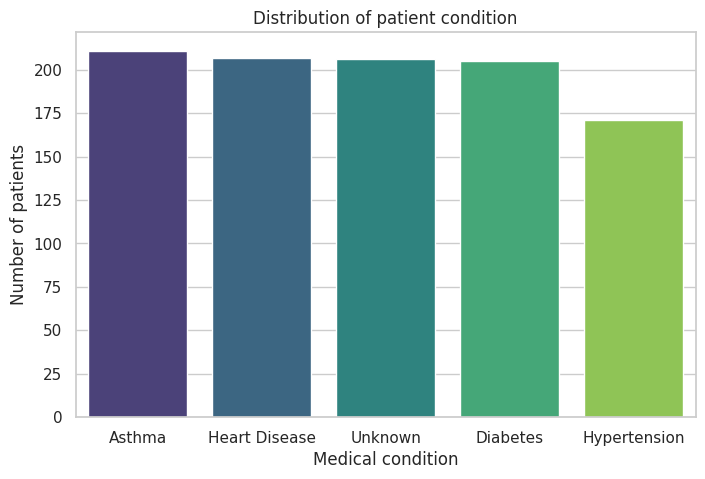

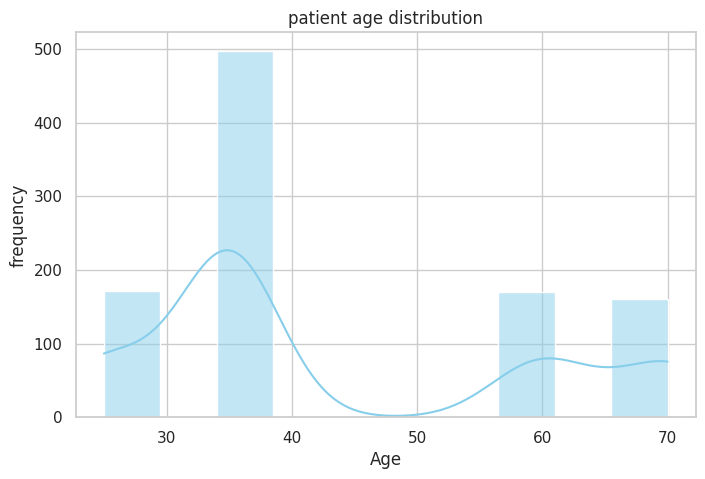

/tmp/ipykernel_1566/3776133581.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1566/3776133581.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


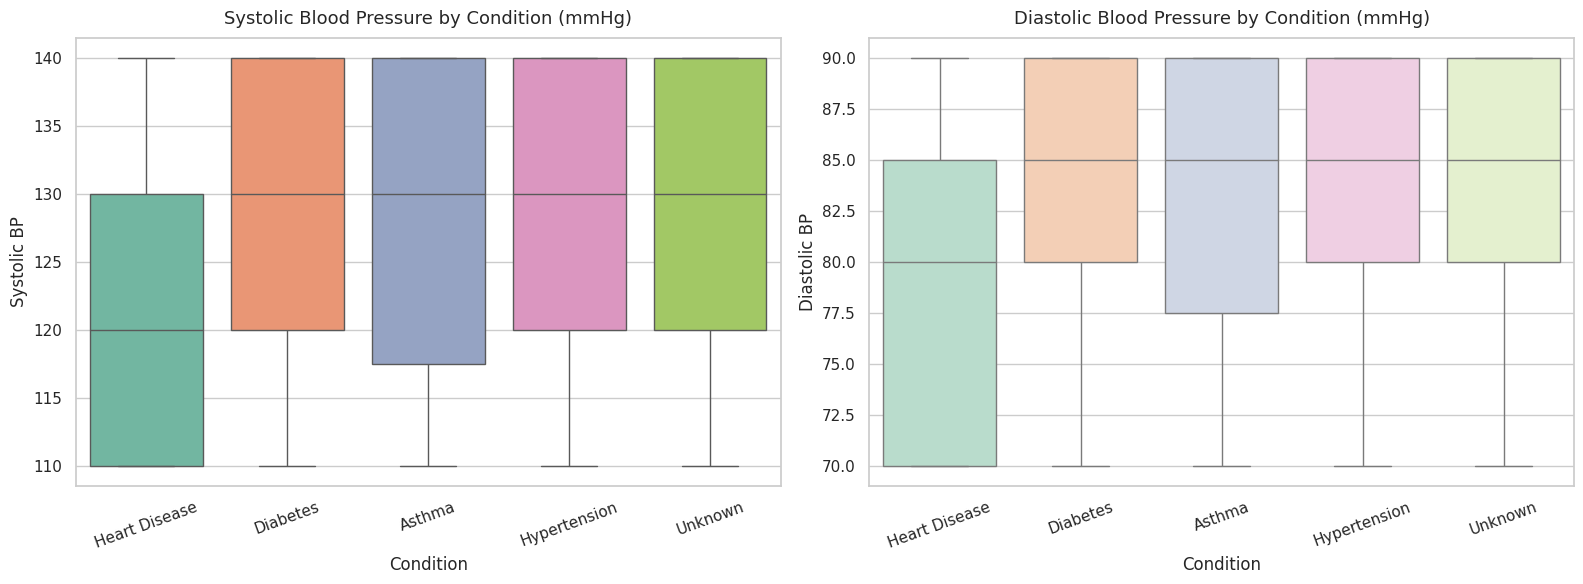

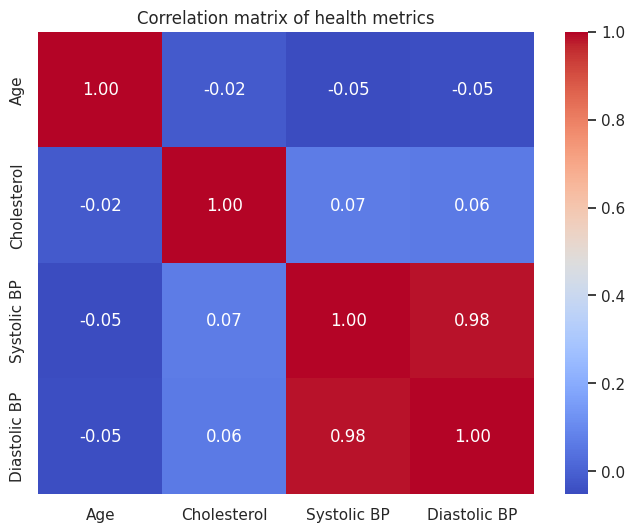

In [22]:
# phase 2 is Exploratory Data Analysis (EDA)

# basic statistical overview
print("statistical summary")
print(df[['Age', 'Cholesterol', 'Systolic BP', 'Diastolic BP']].describe())
print("\n")

# the style of the charts will be white grid
sns.set_theme(style="whitegrid")

# now i will create charts to visualize and analyse to answer some questions

# the first analysis is what are the most common condition (categorical analysis)
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Condition', order=df['Condition'].value_counts().index, palette = 'viridis')
plt.title('Distribution of patient condition')
plt.ylabel('Number of patients')
plt.xlabel('Medical condition')
plt.show()

# second analysis is age distribution (demographic analysis) to see if patients are mostly older or younger or even
plt.figure(figsize=(8, 5))
sns.histplot(df['Age'], bins=10, kde=True, color='skyblue')
plt.title('patient age distribution')
plt.xlabel('Age')
plt.ylabel('frequency')
plt.show()

# third analysis is comparative analysis to to see blood pressure by condition

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)
sns.set_theme(style="whitegrid")

# 1. Systolic BP (Pumping Pressure)
sns.boxplot(
    data=df,
    x='Condition',
    y='Systolic BP',
    palette='Set2',
    ax=axes[0]
)
axes[0].set_title('Systolic Blood Pressure by Condition (mmHg)', fontsize=13, pad=10)
axes[0].set_ylabel('Systolic BP')
axes[0].set_xlabel('Condition')
axes[0].tick_params(axis='x', rotation=20)

# 2. Diastolic BP (Resting Pressure)
sns.boxplot(
    data=df,
    x='Condition',
    y='Diastolic BP',
    palette='Pastel2',
    ax=axes[1]
)
axes[1].set_title('Diastolic Blood Pressure by Condition (mmHg)', fontsize=13, pad=10)
axes[1].set_ylabel('Diastolic BP')
axes[1].set_xlabel('Condition')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()


# fourth analysis is correlation analysis to find hidden relationships by using heatmap
plt.figure(figsize=(8, 6))
numeric_cols = df[['Age', 'Cholesterol', 'Systolic BP', 'Diastolic BP']]
correlation_matrix = numeric_cols.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation matrix of health metrics')
plt.show()


In [27]:
#Phase 3 which is feature engineering by transforming numbers into categories

# Demographic binning which is grouping specific ages into buckets for reporting purposes

bins = [0, 29, 55, 100]
labels = ['Young', 'Middle-aged', 'Senior']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, include_lowest=True)

# By extracting date that has year and month will help in analyzing hospital visits.
df['Visit_Year'] = df['Visit Date'].dt.year
df['Visit_Month'] = df['Visit Date'].dt.month

# By using numpy, I can create custome risk categories and health score metric.
df['Risk_Category'] = np.where(
    (df['Systolic BP'] >= 140) | (df['Cholesterol'] >= 200),
    'High Risk',
    'Low Risk'
)

# creating health score
df['Risk_Score'] = 0

df.loc[df['Systolic BP'] >= 130, 'Risk_Score'] += 1
df.loc[df['Cholesterol'] >= 200, 'Risk_Score'] += 1

severe_conditions = ['Heart Disease', 'Hypertension', 'Diabetes', 'Asthma', 'Cancer']
df.loc[df['Condition'].isin(severe_conditions), 'Risk_Score'] += 1

print("Newly engineered features")
print(df[['Patient Name', 'Age_Group', 'Risk_Category', 'Risk_Score']].head(10))

Newly engineered features
       Patient Name    Age_Group Risk_Category  Risk_Score
0        David Lee         Young     High Risk           3
1      Emily Davis   Middle-aged     High Risk           2
2   Laura Martinez   Middle-aged      Low Risk           1
3   Michael Wilson   Middle-aged      Low Risk           1
4        David Lee   Middle-aged      Low Risk           1
5       Mary Clark   Middle-aged     High Risk           2
6     Robert Brown   Middle-aged      Low Risk           1
7        David Lee        Senior      Low Risk           0
8   Laura Martinez        Senior     High Risk           2
9   Michael Wilson   Middle-aged     High Risk           2


In [31]:
df.to_csv('healthcare_cleaned_data.csv', index=False)
print("Cleaned data exported to 'healthcare_cleaned_data.csv'")

Cleaned data exported to 'healthcare_cleaned_data.csv'
